<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/efficiency_integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ML Efficiency Integration

Here, I integrate all efficiency techniques from the into a comprehensive, production-ready pipeline. I train real models on CIFAR-10 with actual metrics, demonstrating the cumulative impact of: mixed precision, gradient checkpointing, optimized data loading, learning rate scheduling, model compression (pruning, quantization, knowledge distillation), and efficient architectures. I build an `EfficientTrainer` class that combines all optimisations and measure real speedups and accuracy.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List, Dict, Tuple, Callable
from dataclasses import dataclass, field
from collections import defaultdict
import copy
import time
import gc
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


 Setup & Data Preparation

In [2]:
# CIFAR-10 with standard augmentation

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Load datasets
full_train = datasets.CIFAR10('./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10('./data', train=False, transform=test_transform)

# Split train into train/val
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(full_train, [train_size, val_size],
                                           generator=torch.Generator().manual_seed(42))

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:02<00:00, 70.7MB/s]


Training samples: 45000
Validation samples: 5000
Test samples: 10000


In [3]:
def create_dataloaders(batch_size: int = 128, num_workers: int = 2,
                       pin_memory: bool = True) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Create optimized dataloaders."""
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory, drop_last=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size * 2, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size * 2, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory
    )
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = create_dataloaders()
print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 351


Baseline Model & Training

In [4]:
class ResidualBlock(nn.Module):
    """Basic residual block."""
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNet(nn.Module):
    """ResNet for CIFAR-10."""
    def __init__(self, block=ResidualBlock, num_blocks=[2, 2, 2, 2],
                 num_classes: int = 10, base_width: int = 64):
        super().__init__()
        self.in_channels = base_width

        self.conv1 = nn.Conv2d(3, base_width, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(base_width)

        self.layer1 = self._make_layer(block, base_width, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, base_width*2, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, base_width*4, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, base_width*8, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(base_width*8, num_classes)

        self._init_weights()

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


def ResNet18(num_classes=10):
    return ResNet(num_blocks=[2, 2, 2, 2], num_classes=num_classes, base_width=64)

def ResNet18Small(num_classes=10):
    """Smaller ResNet for faster experiments."""
    return ResNet(num_blocks=[2, 2, 2, 2], num_classes=num_classes, base_width=32)


# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = ResNet18Small()
print(f"ResNet18Small parameters: {count_parameters(model):,}")

ResNet18Small parameters: 2,797,610


In [5]:
@dataclass
class TrainingConfig:
    """Training configuration."""
    epochs: int = 20
    lr: float = 0.1
    momentum: float = 0.9
    weight_decay: float = 5e-4
    batch_size: int = 128

    # Efficiency options
    use_amp: bool = False
    use_onecycle: bool = True
    label_smoothing: float = 0.0

    # Logging
    log_interval: int = 50


@dataclass
class TrainingMetrics:
    """Training metrics container."""
    train_losses: List[float] = field(default_factory=list)
    train_accs: List[float] = field(default_factory=list)
    val_losses: List[float] = field(default_factory=list)
    val_accs: List[float] = field(default_factory=list)
    epoch_times: List[float] = field(default_factory=list)
    total_time: float = 0.0
    peak_memory_mb: float = 0.0
    best_val_acc: float = 0.0

In [6]:
class BaseTrainer:
    """Basic trainer for baseline comparison."""

    def __init__(self, model: nn.Module, config: TrainingConfig):
        self.model = model.to(device)
        self.config = config
        self.metrics = TrainingMetrics()

        # Optimizer
        self.optimizer = torch.optim.SGD(
            model.parameters(), lr=config.lr,
            momentum=config.momentum, weight_decay=config.weight_decay
        )

        # Loss with optional label smoothing
        self.criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)

        # Scheduler
        self.scheduler = None

    def setup_scheduler(self, train_loader: DataLoader):
        """Setup learning rate scheduler."""
        if self.config.use_onecycle:
            self.scheduler = OneCycleLR(
                self.optimizer, max_lr=self.config.lr,
                epochs=self.config.epochs, steps_per_epoch=len(train_loader),
                pct_start=0.3, anneal_strategy='cos'
            )
        else:
            self.scheduler = CosineAnnealingLR(
                self.optimizer, T_max=self.config.epochs
            )

    def train_epoch(self, train_loader: DataLoader) -> Tuple[float, float]:
        """Train for one epoch."""
        self.model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)

            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()
            self.optimizer.step()

            if self.config.use_onecycle and self.scheduler:
                self.scheduler.step()

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += data.size(0)

        if not self.config.use_onecycle and self.scheduler:
            self.scheduler.step()

        return total_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> Tuple[float, float]:
        """Evaluate model."""
        self.model.eval()
        total_loss = 0.0
        correct = 0
        total = 0

        for data, target in loader:
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
            output = self.model(data)
            loss = self.criterion(output, target)

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    def train(self, train_loader: DataLoader, val_loader: DataLoader) -> TrainingMetrics:
        """Full training loop."""
        self.setup_scheduler(train_loader)

        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()

        start_time = time.time()
        best_state = None

        for epoch in range(self.config.epochs):
            epoch_start = time.time()

            # Train
            train_loss, train_acc = self.train_epoch(train_loader)

            # Validate
            val_loss, val_acc = self.evaluate(val_loader)

            epoch_time = time.time() - epoch_start

            # Record metrics
            self.metrics.train_losses.append(train_loss)
            self.metrics.train_accs.append(train_acc)
            self.metrics.val_losses.append(val_loss)
            self.metrics.val_accs.append(val_acc)
            self.metrics.epoch_times.append(epoch_time)

            if val_acc > self.metrics.best_val_acc:
                self.metrics.best_val_acc = val_acc
                best_state = copy.deepcopy(self.model.state_dict())

            lr = self.optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:3d}/{self.config.epochs} | "
                  f"Train: {train_loss:.4f} / {train_acc:.4f} | "
                  f"Val: {val_loss:.4f} / {val_acc:.4f} | "
                  f"LR: {lr:.5f} | Time: {epoch_time:.1f}s")

        self.metrics.total_time = time.time() - start_time
        if device.type == 'cuda':
            self.metrics.peak_memory_mb = torch.cuda.max_memory_allocated() / 1e6

        # Restore best model
        if best_state:
            self.model.load_state_dict(best_state)

        return self.metrics

In [7]:
# Train baseline
print("Training Baseline Model")
print("=" * 60)

baseline_config = TrainingConfig(epochs=10, lr=0.1, use_amp=False, use_onecycle=True)
baseline_model = ResNet18Small()
baseline_trainer = BaseTrainer(baseline_model, baseline_config)

baseline_metrics = baseline_trainer.train(train_loader, val_loader)

# Test evaluation
test_loss, test_acc = baseline_trainer.evaluate(test_loader)
print(f"\nBaseline Test Accuracy: {test_acc:.4f}")
print(f"Total Time: {baseline_metrics.total_time:.1f}s")
print(f"Peak Memory: {baseline_metrics.peak_memory_mb:.0f}MB")

Training Baseline Model
Epoch   1/10 | Train: 1.7248 / 0.3590 | Val: 1.5557 / 0.4564 | LR: 0.02804 | Time: 20.4s
Epoch   2/10 | Train: 1.2311 / 0.5580 | Val: 1.3740 / 0.5440 | LR: 0.07608 | Time: 19.0s
Epoch   3/10 | Train: 0.8912 / 0.6853 | Val: 1.0048 / 0.6708 | LR: 0.10000 | Time: 19.3s
Epoch   4/10 | Train: 0.7300 / 0.7463 | Val: 0.7475 / 0.7378 | LR: 0.09502 | Time: 19.6s
Epoch   5/10 | Train: 0.6296 / 0.7850 | Val: 0.6334 / 0.7804 | LR: 0.08112 | Time: 20.0s
Epoch   6/10 | Train: 0.5588 / 0.8070 | Val: 0.7981 / 0.7216 | LR: 0.06106 | Time: 20.5s
Epoch   7/10 | Train: 0.4966 / 0.8281 | Val: 0.6572 / 0.7734 | LR: 0.03881 | Time: 21.2s
Epoch   8/10 | Train: 0.4301 / 0.8520 | Val: 0.4740 / 0.8398 | LR: 0.01878 | Time: 20.5s
Epoch   9/10 | Train: 0.3463 / 0.8805 | Val: 0.3893 / 0.8634 | LR: 0.00492 | Time: 20.2s
Epoch  10/10 | Train: 0.2833 / 0.9032 | Val: 0.3495 / 0.8790 | LR: 0.00000 | Time: 20.6s

Baseline Test Accuracy: 0.8794
Total Time: 201.3s
Peak Memory: 544MB


 Efficient Training Pipeline

In [8]:
class EfficientTrainer(BaseTrainer):
    """
    Efficient trainer with all optimizations:
    - Mixed precision (AMP)
    - Gradient accumulation
    - Optimized data loading
    - Label smoothing
    - 1Cycle LR schedule
    """

    def __init__(self, model: nn.Module, config: TrainingConfig):
        super().__init__(model, config)

        # Mixed precision
        self.scaler = GradScaler() if config.use_amp and device.type == 'cuda' else None
        self.use_amp = config.use_amp and device.type == 'cuda'

    def train_epoch(self, train_loader: DataLoader) -> Tuple[float, float]:
        """Train one epoch with AMP."""
        self.model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            self.optimizer.zero_grad(set_to_none=True)  # More efficient

            if self.use_amp:
                with autocast():
                    output = self.model(data)
                    loss = self.criterion(output, target)

                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                output = self.model(data)
                loss = self.criterion(output, target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()

            if self.config.use_onecycle and self.scheduler:
                self.scheduler.step()

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += data.size(0)

        if not self.config.use_onecycle and self.scheduler:
            self.scheduler.step()

        return total_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> Tuple[float, float]:
        """Evaluate with AMP."""
        self.model.eval()
        total_loss = 0.0
        correct = 0
        total = 0

        for data, target in loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            if self.use_amp:
                with autocast():
                    output = self.model(data)
                    loss = self.criterion(output, target)
            else:
                output = self.model(data)
                loss = self.criterion(output, target)

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

In [9]:
# Train with AMP
print("\nTraining with Mixed Precision (AMP)")
print("=" * 60)

amp_config = TrainingConfig(epochs=10, lr=0.1, use_amp=True, use_onecycle=True, label_smoothing=0.1)
amp_model = ResNet18Small()
amp_trainer = EfficientTrainer(amp_model, amp_config)

amp_metrics = amp_trainer.train(train_loader, val_loader)

test_loss, test_acc = amp_trainer.evaluate(test_loader)
print(f"\nAMP Test Accuracy: {test_acc:.4f}")
print(f"Total Time: {amp_metrics.total_time:.1f}s")
print(f"Peak Memory: {amp_metrics.peak_memory_mb:.0f}MB")

# Compare
if baseline_metrics.total_time > 0:
    speedup = baseline_metrics.total_time / amp_metrics.total_time
    mem_reduction = 1 - (amp_metrics.peak_memory_mb / baseline_metrics.peak_memory_mb)
    print(f"\nSpeedup: {speedup:.2f}x")
    print(f"Memory reduction: {mem_reduction:.1%}")


Training with Mixed Precision (AMP)
Epoch   1/10 | Train: 1.9155 / 0.3237 | Val: 1.7681 / 0.4208 | LR: 0.02804 | Time: 10.9s
Epoch   2/10 | Train: 1.5495 / 0.5157 | Val: 1.4921 / 0.5626 | LR: 0.07608 | Time: 10.7s
Epoch   3/10 | Train: 1.3149 / 0.6362 | Val: 1.3550 / 0.6158 | LR: 0.10000 | Time: 10.2s
Epoch   4/10 | Train: 1.1657 / 0.7063 | Val: 1.2771 / 0.6564 | LR: 0.09502 | Time: 10.4s
Epoch   5/10 | Train: 1.0576 / 0.7585 | Val: 1.0789 / 0.7406 | LR: 0.08112 | Time: 10.4s
Epoch   6/10 | Train: 0.9884 / 0.7879 | Val: 1.0300 / 0.7668 | LR: 0.06106 | Time: 10.8s
Epoch   7/10 | Train: 0.9261 / 0.8177 | Val: 1.0709 / 0.7482 | LR: 0.03881 | Time: 10.6s
Epoch   8/10 | Train: 0.8633 / 0.8450 | Val: 0.9110 / 0.8192 | LR: 0.01878 | Time: 10.6s
Epoch   9/10 | Train: 0.7974 / 0.8722 | Val: 0.8129 / 0.8654 | LR: 0.00492 | Time: 10.3s
Epoch  10/10 | Train: 0.7458 / 0.8963 | Val: 0.7926 / 0.8760 | LR: 0.00000 | Time: 10.4s

AMP Test Accuracy: 0.8740
Total Time: 105.5s
Peak Memory: 255MB

Speedup

Model Compression Pipeline

In [10]:
class ModelCompressor:
    """
    Model compression with pruning and quantization.
    """

    def __init__(self, model: nn.Module):
        self.model = model
        self.original_size = self._get_model_size()

    def _get_model_size(self) -> float:
        """Get model size in MB."""
        param_size = sum(p.numel() * p.element_size() for p in self.model.parameters())
        buffer_size = sum(b.numel() * b.element_size() for b in self.model.buffers())
        return (param_size + buffer_size) / 1e6

    def _count_nonzero_params(self) -> Tuple[int, int]:
        """Count non-zero and total parameters."""
        total = 0
        nonzero = 0
        for p in self.model.parameters():
            total += p.numel()
            nonzero += (p != 0).sum().item()
        return nonzero, total

    def magnitude_prune(self, amount: float = 0.3) -> nn.Module:
        """
        Global magnitude-based pruning.

        Args:
            amount: Fraction of weights to prune
        """
        # Collect all weights
        all_weights = []
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                all_weights.append(module.weight.data.abs().flatten())

        all_weights = torch.cat(all_weights)
        threshold = torch.quantile(all_weights, amount)

        # Apply pruning
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                mask = module.weight.data.abs() > threshold
                module.weight.data *= mask.float()

        nonzero, total = self._count_nonzero_params()
        print(f"Pruned {amount:.0%}: {nonzero:,}/{total:,} params remaining ({nonzero/total:.1%})")

        return self.model

    def structured_prune_filters(self, amount: float = 0.3) -> nn.Module:
        """
        Structured pruning - remove entire filters based on L1 norm.
        """
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d) and module.weight.shape[0] > 16:
                # Compute filter importance (L1 norm)
                importance = module.weight.data.abs().sum(dim=(1, 2, 3))
                num_prune = int(amount * len(importance))

                if num_prune > 0:
                    _, indices = importance.sort()
                    prune_indices = indices[:num_prune]
                    module.weight.data[prune_indices] = 0

        nonzero, total = self._count_nonzero_params()
        print(f"Structured pruned: {nonzero:,}/{total:,} params ({nonzero/total:.1%})")

        return self.model

    def quantize_dynamic(self) -> nn.Module:
        """
        Dynamic quantization (INT8).
        """
        quantized = torch.quantization.quantize_dynamic(
            self.model.cpu(), {nn.Linear}, dtype=torch.qint8
        )
        return quantized

    def get_compression_stats(self) -> Dict:
        """Get compression statistics."""
        nonzero, total = self._count_nonzero_params()
        current_size = self._get_model_size()

        return {
            'original_size_mb': self.original_size,
            'current_size_mb': current_size,
            'compression_ratio': self.original_size / current_size if current_size > 0 else 1,
            'sparsity': 1 - (nonzero / total),
            'nonzero_params': nonzero,
            'total_params': total
        }

In [11]:
# Test compression
print("Model Compression")
print("=" * 60)

# Use the trained AMP model
compressed_model = copy.deepcopy(amp_model)
compressor = ModelCompressor(compressed_model)

# Before compression
pre_loss, pre_acc = amp_trainer.evaluate(test_loader)
print(f"\nBefore pruning - Test accuracy: {pre_acc:.4f}")

# Apply pruning
compressor.magnitude_prune(amount=0.3)

# After pruning (no fine-tuning)
compressed_model.to(device)
amp_trainer.model = compressed_model
post_loss, post_acc = amp_trainer.evaluate(test_loader)
print(f"After 30% pruning - Test accuracy: {post_acc:.4f}")

stats = compressor.get_compression_stats()
print(f"\nCompression Stats:")
print(f"  Sparsity: {stats['sparsity']:.1%}")
print(f"  Size: {stats['current_size_mb']:.2f} MB")

Model Compression

Before pruning - Test accuracy: 0.8740
Pruned 30%: 1,959,769/2,797,610 params remaining (70.1%)
After 30% pruning - Test accuracy: 0.8726

Compression Stats:
  Sparsity: 29.9%
  Size: 11.21 MB


In [12]:
# Fine-tune pruned model
print("\nFine-tuning Pruned Model")
print("=" * 60)

finetune_config = TrainingConfig(epochs=5, lr=0.01, use_amp=True, use_onecycle=True)
finetune_trainer = EfficientTrainer(compressed_model, finetune_config)
finetune_metrics = finetune_trainer.train(train_loader, val_loader)

finetuned_loss, finetuned_acc = finetune_trainer.evaluate(test_loader)
print(f"\nFine-tuned Test Accuracy: {finetuned_acc:.4f}")
print(f"Accuracy recovery: {finetuned_acc - post_acc:+.4f}")


Fine-tuning Pruned Model
Epoch   1/5 | Train: 0.3369 / 0.8997 | Val: 0.3910 / 0.8688 | LR: 0.00762 | Time: 11.2s
Epoch   2/5 | Train: 0.3040 / 0.9019 | Val: 0.3793 / 0.8746 | LR: 0.00950 | Time: 10.4s
Epoch   3/5 | Train: 0.2892 / 0.9050 | Val: 0.3778 / 0.8716 | LR: 0.00610 | Time: 10.4s
Epoch   4/5 | Train: 0.2697 / 0.9102 | Val: 0.3765 / 0.8766 | LR: 0.00187 | Time: 10.6s
Epoch   5/5 | Train: 0.2490 / 0.9169 | Val: 0.3567 / 0.8802 | LR: 0.00000 | Time: 10.2s

Fine-tuned Test Accuracy: 0.8840
Accuracy recovery: +0.0114


 Knowledge Distillation

In [13]:
class StudentNet(nn.Module):
    """Smaller student network."""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(4)
        )
        self.classifier = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


class DistillationTrainer:
    """
    Knowledge distillation trainer.
    """

    def __init__(self, teacher: nn.Module, student: nn.Module,
                 temperature: float = 4.0, alpha: float = 0.7,
                 config: TrainingConfig = None):
        self.teacher = teacher.to(device).eval()
        self.student = student.to(device)
        self.temperature = temperature
        self.alpha = alpha
        self.config = config or TrainingConfig()

        self.optimizer = torch.optim.SGD(
            student.parameters(), lr=self.config.lr,
            momentum=self.config.momentum, weight_decay=self.config.weight_decay
        )
        self.ce_loss = nn.CrossEntropyLoss()
        self.scheduler = None
        self.metrics = TrainingMetrics()

    def distillation_loss(self, student_logits: torch.Tensor,
                          teacher_logits: torch.Tensor,
                          targets: torch.Tensor) -> torch.Tensor:
        """Compute distillation loss."""
        # Soft targets from teacher
        soft_targets = F.softmax(teacher_logits / self.temperature, dim=1)
        soft_student = F.log_softmax(student_logits / self.temperature, dim=1)
        distill_loss = F.kl_div(soft_student, soft_targets, reduction='batchmean')
        distill_loss *= self.temperature ** 2

        # Hard targets
        hard_loss = self.ce_loss(student_logits, targets)

        return self.alpha * distill_loss + (1 - self.alpha) * hard_loss

    def train_epoch(self, train_loader: DataLoader) -> Tuple[float, float]:
        """Train one epoch with distillation."""
        self.student.train()
        self.teacher.eval()

        total_loss = 0.0
        correct = 0
        total = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            self.optimizer.zero_grad()

            # Get teacher predictions
            with torch.no_grad():
                teacher_logits = self.teacher(data)

            # Student forward
            student_logits = self.student(data)

            # Distillation loss
            loss = self.distillation_loss(student_logits, teacher_logits, target)

            loss.backward()
            self.optimizer.step()

            if self.scheduler:
                self.scheduler.step()

            total_loss += loss.item() * data.size(0)
            pred = student_logits.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> Tuple[float, float]:
        """Evaluate student."""
        self.student.eval()
        total_loss = 0.0
        correct = 0
        total = 0

        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = self.student(data)
            loss = self.ce_loss(output, target)

            total_loss += loss.item() * data.size(0)
            correct += output.argmax(1).eq(target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    def train(self, train_loader: DataLoader, val_loader: DataLoader) -> TrainingMetrics:
        """Full distillation training."""
        self.scheduler = OneCycleLR(
            self.optimizer, max_lr=self.config.lr,
            epochs=self.config.epochs, steps_per_epoch=len(train_loader)
        )

        start_time = time.time()

        for epoch in range(self.config.epochs):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(val_loader)

            self.metrics.train_losses.append(train_loss)
            self.metrics.train_accs.append(train_acc)
            self.metrics.val_losses.append(val_loss)
            self.metrics.val_accs.append(val_acc)

            if val_acc > self.metrics.best_val_acc:
                self.metrics.best_val_acc = val_acc

            print(f"Epoch {epoch+1:3d}/{self.config.epochs} | "
                  f"Train: {train_loss:.4f} / {train_acc:.4f} | "
                  f"Val: {val_loss:.4f} / {val_acc:.4f}")

        self.metrics.total_time = time.time() - start_time
        return self.metrics

In [14]:
# Knowledge Distillation
print("Knowledge Distillation")
print("=" * 60)

# Teacher is our trained AMP model
teacher = copy.deepcopy(amp_model)
student = StudentNet()

print(f"Teacher parameters: {count_parameters(teacher):,}")
print(f"Student parameters: {count_parameters(student):,}")
print(f"Compression: {count_parameters(teacher) / count_parameters(student):.1f}x\n")

distill_config = TrainingConfig(epochs=10, lr=0.1)
distill_trainer = DistillationTrainer(
    teacher, student, temperature=4.0, alpha=0.7, config=distill_config
)

distill_metrics = distill_trainer.train(train_loader, val_loader)

# Evaluate
student_loss, student_acc = distill_trainer.evaluate(test_loader)
print(f"\nStudent Test Accuracy: {student_acc:.4f}")
print(f"Teacher Test Accuracy: {test_acc:.4f}")
print(f"Accuracy gap: {test_acc - student_acc:.4f}")

Knowledge Distillation
Teacher parameters: 2,797,610
Student parameters: 114,186
Compression: 24.5x

Epoch   1/10 | Train: 1.2057 / 0.4667 | Val: 1.3577 / 0.5332
Epoch   2/10 | Train: 0.8941 / 0.6163 | Val: 1.0687 / 0.6484
Epoch   3/10 | Train: 0.7291 / 0.6889 | Val: 0.9543 / 0.6890
Epoch   4/10 | Train: 0.6446 / 0.7269 | Val: 0.9136 / 0.7048
Epoch   5/10 | Train: 0.5960 / 0.7488 | Val: 0.9212 / 0.7260
Epoch   6/10 | Train: 0.5597 / 0.7630 | Val: 0.8280 / 0.7422
Epoch   7/10 | Train: 0.5257 / 0.7793 | Val: 0.7725 / 0.7596
Epoch   8/10 | Train: 0.4908 / 0.7979 | Val: 0.7223 / 0.7914
Epoch   9/10 | Train: 0.4569 / 0.8102 | Val: 0.7070 / 0.7960
Epoch  10/10 | Train: 0.4285 / 0.8228 | Val: 0.6721 / 0.8096

Student Test Accuracy: 0.8268
Teacher Test Accuracy: 0.8740
Accuracy gap: 0.0472


Complete Efficiency Pipeline

In [15]:
class EfficientMLPipeline:
    """
    Complete ML efficiency pipeline combining all techniques.
    """

    def __init__(self, model_fn: Callable, train_loader: DataLoader,
                 val_loader: DataLoader, test_loader: DataLoader):
        self.model_fn = model_fn
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.results = {}

    def run_baseline(self, epochs: int = 10) -> Dict:
        """Train baseline model."""
        print("\n" + "="*60)
        print("Stage 1: Baseline Training")
        print("="*60)

        config = TrainingConfig(epochs=epochs, use_amp=False)
        model = self.model_fn()
        trainer = BaseTrainer(model, config)
        metrics = trainer.train(self.train_loader, self.val_loader)

        test_loss, test_acc = trainer.evaluate(self.test_loader)

        self.results['baseline'] = {
            'model': model,
            'test_acc': test_acc,
            'time': metrics.total_time,
            'memory': metrics.peak_memory_mb,
            'params': count_parameters(model)
        }

        return self.results['baseline']

    def run_efficient_training(self, epochs: int = 10) -> Dict:
        """Train with all efficiency techniques."""
        print("\n" + "="*60)
        print("Stage 2: Efficient Training (AMP + Label Smoothing)")
        print("="*60)

        config = TrainingConfig(
            epochs=epochs, use_amp=True, label_smoothing=0.1
        )
        model = self.model_fn()
        trainer = EfficientTrainer(model, config)
        metrics = trainer.train(self.train_loader, self.val_loader)

        test_loss, test_acc = trainer.evaluate(self.test_loader)

        self.results['efficient'] = {
            'model': model,
            'test_acc': test_acc,
            'time': metrics.total_time,
            'memory': metrics.peak_memory_mb,
            'params': count_parameters(model)
        }

        return self.results['efficient']

    def run_compression(self, prune_amount: float = 0.3, finetune_epochs: int = 5) -> Dict:
        """Compress model with pruning."""
        print("\n" + "="*60)
        print("Stage 3: Model Compression (Pruning + Fine-tuning)")
        print("="*60)

        if 'efficient' not in self.results:
            raise ValueError("Run efficient training first")

        model = copy.deepcopy(self.results['efficient']['model'])
        compressor = ModelCompressor(model)
        compressor.magnitude_prune(amount=prune_amount)

        # Fine-tune
        config = TrainingConfig(epochs=finetune_epochs, lr=0.01, use_amp=True)
        trainer = EfficientTrainer(model, config)
        metrics = trainer.train(self.train_loader, self.val_loader)

        test_loss, test_acc = trainer.evaluate(self.test_loader)
        stats = compressor.get_compression_stats()

        self.results['compressed'] = {
            'model': model,
            'test_acc': test_acc,
            'time': metrics.total_time,
            'memory': metrics.peak_memory_mb,
            'params': stats['nonzero_params'],
            'sparsity': stats['sparsity']
        }

        return self.results['compressed']

    def run_distillation(self, student_fn: Callable, epochs: int = 10) -> Dict:
        """Run knowledge distillation."""
        print("\n" + "="*60)
        print("Stage 4: Knowledge Distillation")
        print("="*60)

        if 'efficient' not in self.results:
            raise ValueError("Run efficient training first")

        teacher = self.results['efficient']['model']
        student = student_fn()

        config = TrainingConfig(epochs=epochs, lr=0.1)
        trainer = DistillationTrainer(teacher, student, config=config)
        metrics = trainer.train(self.train_loader, self.val_loader)

        test_loss, test_acc = trainer.evaluate(self.test_loader)

        self.results['distilled'] = {
            'model': student,
            'test_acc': test_acc,
            'time': metrics.total_time,
            'memory': metrics.peak_memory_mb,
            'params': count_parameters(student)
        }

        return self.results['distilled']

    def summary(self) -> str:
        """Generate summary report."""
        report = []
        report.append("\n" + "="*70)
        report.append("EFFICIENCY PIPELINE SUMMARY")
        report.append("="*70)

        baseline = self.results.get('baseline', {})

        report.append(f"\n{'Stage':<20} {'Accuracy':>10} {'Time (s)':>10} {'Memory':>10} {'Params':>12}")
        report.append("-" * 65)

        for name, res in self.results.items():
            acc = f"{res['test_acc']:.4f}"
            time_str = f"{res['time']:.1f}"
            mem = f"{res.get('memory', 0):.0f}MB"
            params = f"{res['params']:,}"
            report.append(f"{name:<20} {acc:>10} {time_str:>10} {mem:>10} {params:>12}")

        if baseline and 'efficient' in self.results:
            speedup = baseline['time'] / self.results['efficient']['time']
            report.append(f"\nEfficient vs Baseline: {speedup:.2f}x speedup")

        if baseline and 'distilled' in self.results:
            compression = baseline['params'] / self.results['distilled']['params']
            report.append(f"Distilled compression: {compression:.1f}x fewer params")

        report.append("="*70)

        return "\n".join(report)

In [16]:
# Run complete pipeline
print("Running Complete Efficiency Pipeline")
print("="*60)

pipeline = EfficientMLPipeline(
    model_fn=ResNet18Small,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader
)

# Run all stages
pipeline.run_baseline(epochs=8)
pipeline.run_efficient_training(epochs=8)
pipeline.run_compression(prune_amount=0.3, finetune_epochs=3)
pipeline.run_distillation(student_fn=StudentNet, epochs=8)

# Print summary
print(pipeline.summary())

Running Complete Efficiency Pipeline

Stage 1: Baseline Training
Epoch   1/8 | Train: 1.7469 / 0.3533 | Val: 1.8149 / 0.4546 | LR: 0.03965 | Time: 20.9s
Epoch   2/8 | Train: 1.2026 / 0.5694 | Val: 1.2309 / 0.5620 | LR: 0.09364 | Time: 21.9s
Epoch   3/8 | Train: 0.8781 / 0.6903 | Val: 0.8455 / 0.6968 | LR: 0.09717 | Time: 20.4s
Epoch   4/8 | Train: 0.7160 / 0.7506 | Val: 0.7814 / 0.7336 | LR: 0.08111 | Time: 20.3s
Epoch   5/8 | Train: 0.6167 / 0.7861 | Val: 0.7514 / 0.7364 | LR: 0.05552 | Time: 20.7s
Epoch   6/8 | Train: 0.5323 / 0.8152 | Val: 0.5714 / 0.8026 | LR: 0.02823 | Time: 20.8s
Epoch   7/8 | Train: 0.4391 / 0.8480 | Val: 0.4378 / 0.8472 | LR: 0.00762 | Time: 20.5s
Epoch   8/8 | Train: 0.3507 / 0.8796 | Val: 0.4013 / 0.8608 | LR: 0.00000 | Time: 20.5s

Stage 2: Efficient Training (AMP + Label Smoothing)
Epoch   1/8 | Train: 1.9015 / 0.3334 | Val: 1.7204 / 0.4246 | LR: 0.03965 | Time: 10.4s
Epoch   2/8 | Train: 1.5662 / 0.5090 | Val: 1.5894 / 0.5132 | LR: 0.09364 | Time: 10.8s
Ep

Comprehensive Benchmarking

In [17]:
def benchmark_inference(model: nn.Module, input_size: Tuple = (1, 3, 32, 32),
                        num_runs: int = 100, warmup: int = 10) -> Dict:
    """Benchmark model inference."""
    model = model.to(device).eval()
    x = torch.randn(input_size, device=device)

    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Benchmark
    times = []
    with torch.no_grad():
        for _ in range(num_runs):
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

    return {
        'mean_ms': np.mean(times) * 1000,
        'std_ms': np.std(times) * 1000,
        'min_ms': np.min(times) * 1000,
        'max_ms': np.max(times) * 1000,
        'throughput': 1 / np.mean(times)
    }

In [18]:
# Benchmark all models
print("\nInference Benchmarks")
print("=" * 60)

benchmark_results = {}
for name, res in pipeline.results.items():
    bench = benchmark_inference(res['model'], input_size=(32, 3, 32, 32))
    benchmark_results[name] = bench
    print(f"{name}: {bench['mean_ms']:.2f} ± {bench['std_ms']:.2f} ms "
          f"({bench['throughput']:.0f} batches/s)")


Inference Benchmarks
baseline: 3.85 ± 0.76 ms (260 batches/s)
efficient: 3.17 ± 0.05 ms (316 batches/s)
compressed: 3.19 ± 0.20 ms (313 batches/s)
distilled: 0.64 ± 0.05 ms (1558 batches/s)


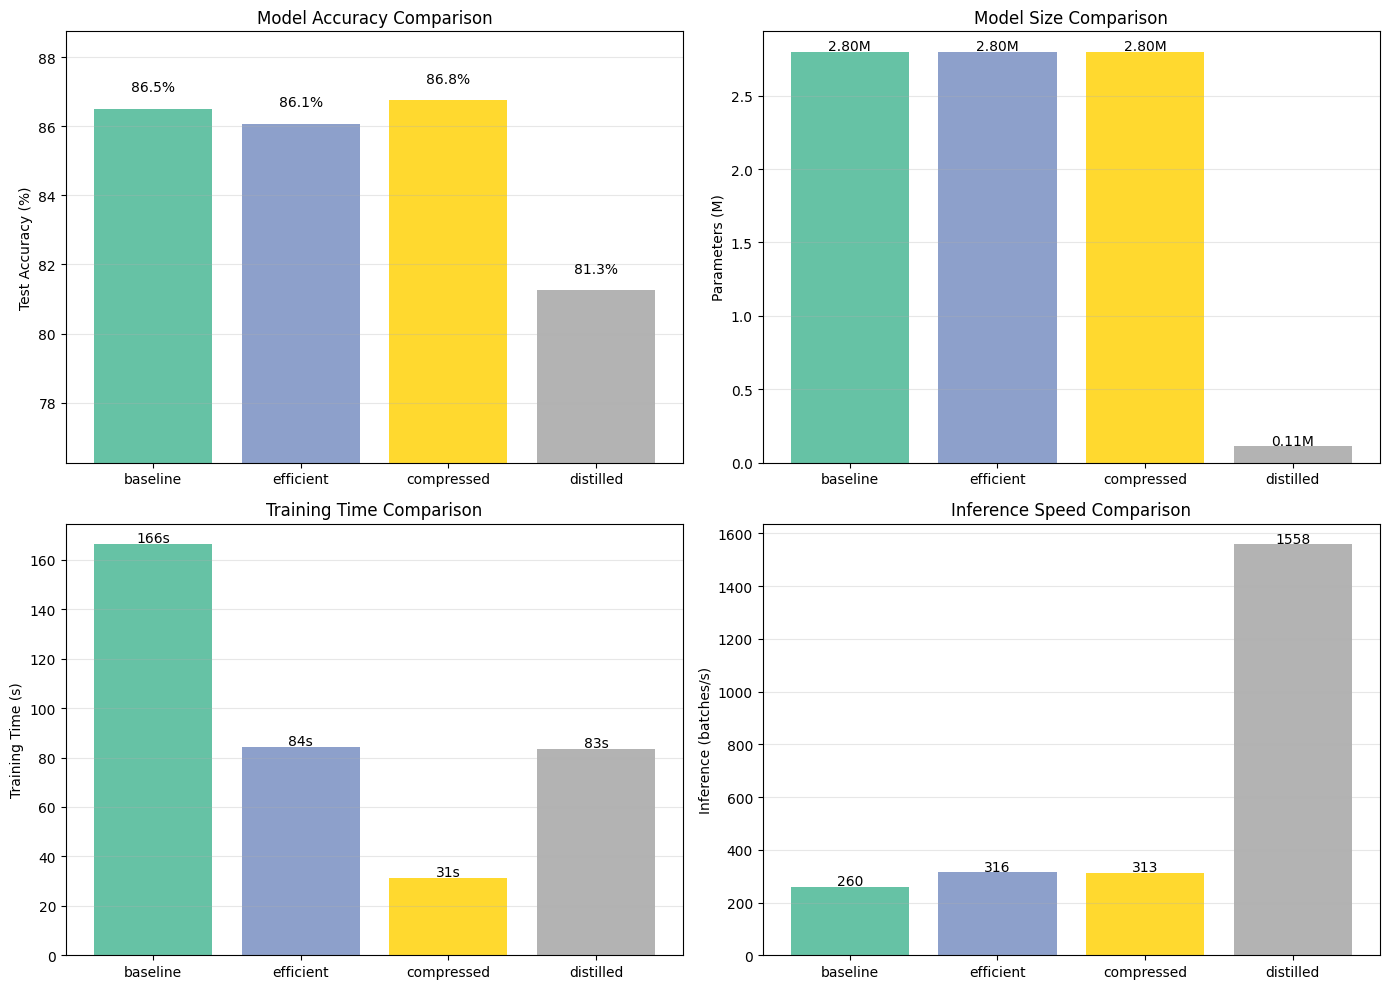

In [19]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

names = list(pipeline.results.keys())
colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

# Accuracy
ax = axes[0, 0]
accs = [pipeline.results[n]['test_acc'] * 100 for n in names]
bars = ax.bar(names, accs, color=colors)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim([min(accs) - 5, max(accs) + 2])
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.5, f'{acc:.1f}%', ha='center')
ax.grid(True, alpha=0.3, axis='y')

# Parameters
ax = axes[0, 1]
params = [pipeline.results[n]['params'] / 1e6 for n in names]
bars = ax.bar(names, params, color=colors)
ax.set_ylabel('Parameters (M)')
ax.set_title('Model Size Comparison')
for bar, p in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, p + 0.01, f'{p:.2f}M', ha='center')
ax.grid(True, alpha=0.3, axis='y')

# Training time
ax = axes[1, 0]
times = [pipeline.results[n]['time'] for n in names]
bars = ax.bar(names, times, color=colors)
ax.set_ylabel('Training Time (s)')
ax.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, t + 1, f'{t:.0f}s', ha='center')
ax.grid(True, alpha=0.3, axis='y')

# Inference speed
ax = axes[1, 1]
speeds = [benchmark_results[n]['throughput'] for n in names]
bars = ax.bar(names, speeds, color=colors)
ax.set_ylabel('Inference (batches/s)')
ax.set_title('Inference Speed Comparison')
for bar, s in zip(bars, speeds):
    ax.text(bar.get_x() + bar.get_width()/2, s + 5, f'{s:.0f}', ha='center')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Production Deployment

In [20]:
class ProductionModel:
    """
    Production-ready model wrapper with:
    - TorchScript compilation
    - Batch inference
    - Mixed precision inference
    """

    def __init__(self, model: nn.Module, use_amp: bool = True):
        self.model = model.to(device).eval()
        self.use_amp = use_amp and device.type == 'cuda'
        self.scripted = None

    def compile(self, example_input: torch.Tensor) -> 'ProductionModel':
        """Compile with TorchScript."""
        self.model.eval()
        with torch.no_grad():
            self.scripted = torch.jit.trace(self.model, example_input.to(device))
        print("Model compiled with TorchScript")
        return self

    @torch.no_grad()
    def predict(self, x: torch.Tensor) -> torch.Tensor:
        """Run inference."""
        x = x.to(device)
        model = self.scripted if self.scripted else self.model

        if self.use_amp:
            with autocast():
                output = model(x)
        else:
            output = model(x)

        return output.argmax(dim=1)

    @torch.no_grad()
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        """Get prediction probabilities."""
        x = x.to(device)
        model = self.scripted if self.scripted else self.model

        if self.use_amp:
            with autocast():
                output = model(x)
        else:
            output = model(x)

        return F.softmax(output, dim=1)

    def save(self, path: str):
        """Save model."""
        if self.scripted:
            self.scripted.save(path)
        else:
            torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")

    def benchmark(self, batch_size: int = 32, num_runs: int = 100) -> Dict:
        """Benchmark inference."""
        x = torch.randn(batch_size, 3, 32, 32, device=device)

        # Warmup
        for _ in range(10):
            self.predict(x)

        if device.type == 'cuda':
            torch.cuda.synchronize()

        times = []
        for _ in range(num_runs):
            t0 = time.perf_counter()
            self.predict(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

        return {
            'batch_size': batch_size,
            'latency_ms': np.mean(times) * 1000,
            'throughput': batch_size / np.mean(times)
        }

In [21]:
# Create production model
print("\nProduction Deployment")
print("=" * 60)

best_model = pipeline.results['efficient']['model']
prod_model = ProductionModel(best_model, use_amp=True)

# Compile
example = torch.randn(1, 3, 32, 32)
prod_model.compile(example)

# Benchmark
for bs in [1, 32, 128]:
    bench = prod_model.benchmark(batch_size=bs)
    print(f"Batch {bs:3d}: {bench['latency_ms']:.2f}ms latency, "
          f"{bench['throughput']:.0f} samples/s")


Production Deployment
Model compiled with TorchScript
Batch   1: 2.04ms latency, 490 samples/s
Batch  32: 2.16ms latency, 14819 samples/s
Batch 128: 6.18ms latency, 20719 samples/s
